In [ ]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("dschettler8845/brats-2021-task1")

# print("Path to dataset files:", path)

d:\cod_licenta\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 12.3G/12.3G [24:38<00:00, 8.93MB/s]  


Extracting files...
Path to dataset files: C:\Users\ingri\.cache\kagglehub\datasets\dschettler8845\brats-2021-task1\versions\1


In [21]:
import os
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch
from torchvision.transforms import Compose, ToTensor
from torchvision import transforms, utils
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim

In [22]:
PATH = "D:/cod_licenta/1/BraTS2021_Training_Data"
patients = os.listdir(PATH)

train_patients = patients[0:len(patients) // 10 * 7]
val_patients = patients[len(patients) // 10 * 7:len(patients) // 10 * 9]
test_patients = patients[len(patients) // 10 * 9:]

print(len(train_patients), len(val_patients), len(test_patients))
print(len(patients)) # 1251 foldere a cate 4 slice-uri 3d + 1 seg
# for folder in os.listdir(PATH):
#     elems = os.listdir(os.path.join(PATH, folder))

875 250 126
1251


In [32]:
class BraTSDataset(Dataset):
    def __init__(self, patients_list : list[str], transforms = None):
        self.groundtruth = []
        self.transforms = transforms
        self.patients_list = patients_list
        self.t1ce = []
        self.t1 = []
        self.t2 = []
        self.flair = []
        for patient in patients_list:
            patient_folder = os.path.join(PATH, patient) # pune path corect pana la fiecare folder cu cate 5 poze si elems e un vect de 5 poze
            for photo_name in os.listdir(patient_folder):
                if "seg.nii.gz" in photo_name:
                    path_photo = os.path.join(patient_folder, photo_name) # path-ul fiecarei poze din fiecare folder al pacientului e pus in vect
                    self.groundtruth.append(path_photo)
                elif "t1ce.nii.gz" in photo_name:
                    path_photo = os.path.join(patient_folder, photo_name) # path-ul fiecarei poze din fiecare folder al pacientului e pus in vect
                    self.t1ce.append(path_photo)
                elif "t1.nii.gz" in photo_name:
                    path_photo = os.path.join(patient_folder, photo_name) 
                    self.t1.append(path_photo)
                elif "t2.nii.gz" in photo_name:
                    path_photo = os.path.join(patient_folder, photo_name)
                    self.t2.append(path_photo)
                elif "flair.nii.gz" in photo_name:
                    path_photo = os.path.join(patient_folder, photo_name)
                    self.flair.append(path_photo)
        # print(self.t1ce)
        # print()
        # print(self.t1)
        # print()
        # print(self.t2)
        # print()
        # print(self.flair)
        # print()
        # print(self.groundtruth)


    def __len__(self): # fctie pt nr de pacienti din dataset
        return len(self.patients_list)

    def __getitem__(self, idx : int): # fctie pt accesarea fiecarei poze t1 si seg de la un anumit index pe care o face tensor
        nii_img = nib.load(self.t1[idx])
        nii_groundtruth = nib.load(self.groundtruth[idx])
        image_data = nii_img.get_fdata()
        groundtruth_data = nii_groundtruth.get_fdata()
        image_data = torch.from_numpy(image_data).float().unsqueeze(dim=0)
        groundtruth_data = torch.from_numpy(groundtruth_data).float().unsqueeze(dim=0)
        return image_data, groundtruth_data
    
    def display_axial_slice(self, idx : int, slice_index=None):
        # Load image
        nii_img = nib.load(self.t1[idx])
        data = nii_img.get_fdata()

        # Choose slice index (z-axis)
        if slice_index is None:
            slice_index = data.shape[2] // 2  # middle slice along axial plane

        # Extract axial slice
        slice_data = data[:, :, slice_index]

        # Plot
        plt.figure(figsize=(6, 6))
        plt.imshow(np.rot90(slice_data), cmap="gray")
        plt.title(f"Axial slice {slice_index}")
        plt.axis("off")
        plt.show()


In [33]:
training_dataset = BraTSDataset(train_patients)
val_dataset = BraTSDataset(val_patients)
test_dataset = BraTSDataset(test_patients)

torch.Size([1, 240, 240, 155]) torch.Size([1, 240, 240, 155])


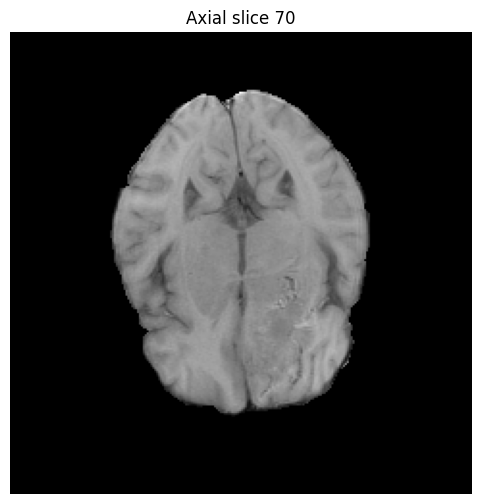

In [41]:
img_data, segmentation_data = training_dataset.__getitem__(0)
print(img_data.shape, segmentation_data.shape)
training_dataset.display_axial_slice(0, 70)


In [ ]:
class Net(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(Net, self).__init__()  # constructor nn.Module si e cu super pt Net il mosteneste
        
        self.encoder = nn.Sequential(
            # o imag are 3 canale RGB, cand o bagi in reteaua neurala cresti nr de canale ca sa fie mai complex
            nn.Conv3d(in_channels, 8, kernel_size=3, padding=1), # creeaza un kernel = matrice de mici dimensiuni folosit pt a vedea daca esti 
            # langa o margine, intr-o imag poti avea mai multe kerneluri
            nn.BatchNorm3d(8), # transforma nr mari din input in nr mici apropiate de 0 pt stabilitate numerica (tot sa fie nr mai mici)
            nn.ReLU(inplace=True), # ReLU  e fctie de activare care face modelul mai complex si mai bun

            nn.Conv3d(8, 16, kernel_size=3, padding=1),
            nn.BatchNorm3d(16),
            nn.ReLU(inplace=True)
        )
        
        self.decoder = nn.Sequential(
            nn.Conv3d(16, 8, kernel_size=3, padding=1),
            nn.BatchNorm3d(8),
            nn.ReLU(inplace=True),

            nn.Conv3d(8, out_channels, kernel_size=1)  # segmentation logits
        )
        self.softmax = nn.Softmax(dim=1) # softmax e fctie de activare, imi aduce inputul in intervalul 0-1 ca sa fie vazut ca probabilitati

    def forward(self, x): # fctie care arata cum se parcurge reteaua neurala
        x = self.encoder(x)
        x = self.decoder(x)
        return self.softmax(x)  # shape: (B, out_channels, D, H, W)

net = Net() # initializare retea
input, seg = next(iter(dataloader)) # selectam random o poza si un groundtruth din dataloader
print(input.shape) # dimensiunea unei poze
print(seg.shape)
# tensor = matricea tuturor imaginilor in cazul asta, poate sa fie si doar o imag, se pune mereu la retele neurale
print(torch.unique(seg)) # ia cate o valoare a unui pixel din tensor doar o data chiar daca se repeta
# 0. 2. 3. 4. CRED ca sunt clasele ca si cum glioma etc
print(torch.max(seg), torch.min(seg)) #max si min din tensor, in cazul imag maximul e alb-255 si ia valoarea cea mai apropiata
# daca min=0 si max=1 => matricea e normalizata si vrem asta ca imbunatateste antrenarea retelei
# la noi nu e normalizat
y = net(input) # rezultatul rularii retelei pe imagini
print(y.shape) # rezultatul trebuie sa fie tot de tip tensor si de-aia ii afisam dimensiunea

# matt = [
#     [1, 2, 3]
#     [4, 5, 6]
# ]
# tensorrr = torch.tensor(matt)
